# Models 1 and 2: Linear Regression and XGBoost

## Purpose

The goal of this analysis is to predict DoorDash delivery duration using two different regression approaches. Linear Regression provides a straightforward starting point, while XGBoost allows us to explore whether more complex relationships between the predictors can improve prediction accuracy.

Both models are evaluated using MAE, RMSE, R², and bias, with a median baseline included for comparison. Validation performance is used for model comparison before final evaluation on the test set.

#### Imports and settings

In [18]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

SEED = 505
TARGET = "delivery_duration"
RESULTS = Path("results")
RESULTS.mkdir(exist_ok=True)

#### Loading prepared datasets

In [2]:
train = pd.read_csv("training.csv")
validation = pd.read_csv("validation.csv")
test = pd.read_csv("test.csv")

print("Training shape:", train.shape)
print("Validation shape:", validation.shape)
print("Test shape:", test.shape)
train.head()

Training shape: (108331, 107)
Validation shape: (36111, 107)
Test shape: (36111, 107)


,delivery_duration,order_hour,order_weekend,total_items,subtotal,min_item_price,max_item_price,num_distinct_items,average_quantity_per_item,total_onshift_dashers,...,order_protocol_5.0,order_protocol_6.0,order_protocol_7.0,order_dayofweek_0,order_dayofweek_1,order_dayofweek_2,order_dayofweek_3,order_dayofweek_4,order_dayofweek_5,order_dayofweek_6
0,60.016667,3,1,4,3180,795,795,1,4.0,58.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,48.633333,17,0,1,604,339,339,1,1.0,5.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,44.833333,0,0,8,5521,499,750,8,1.0,17.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,50.416667,1,1,3,1407,229,479,3,1.0,23.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,48.683333,1,0,4,3540,525,1195,4,1.0,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


#### Seperate predictors and target

In [3]:
X_train = train.drop(columns=[TARGET])
y_train = train[TARGET]
X_validation = validation.drop(columns=[TARGET])
y_validation = validation[TARGET]
X_test = test.drop(columns=[TARGET])
y_test = test[TARGET]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (108331, 106)
y_train: (108331,)
X_validation: (36111, 106)
y_validation: (36111,)
X_test: (36111, 106)
y_test: (36111,)


#### Check modeling data



In [4]:
print("Missing values:")
print("Training:", X_train.isna().sum().sum())
print("Validation:", X_validation.isna().sum().sum())
print("Test:", X_test.isna().sum().sum())
print("\nInfinite values:")
print("Training:", np.isinf(X_train).sum().sum())
print("Validation:", np.isinf(X_validation).sum().sum())
print("Test:", np.isinf(X_test).sum().sum())

Missing values:
Training: 0
Validation: 0
Test: 0

Infinite values:
Training: 0
Validation: 0
Test: 0


In [5]:
# Compare target distributions across datasets

target_summary = pd.DataFrame({
    "Train": y_train.describe()[["mean", "50%", "std", "min", "max"]],
    "Validation": y_validation.describe()[["mean", "50%", "std", "min", "max"]],
    "Test": y_test.describe()[["mean", "50%", "std", "min", "max"]]
})
target_summary.round(2)

,Train,Validation,Test
mean,47.74,47.55,47.46
50%,44.42,44.33,44.28
std,18.57,18.28,18.28
min,1.68,3.72,5.87
max,297.70,262.78,282.23


#### Model 1: Linear Regression

Linear Regression provides a simple baseline for predicting delivery duration before comparing it with a more complex model.

In [6]:
# Fit Linear Regression model

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
print("Linear Regression training complete.")

Linear Regression training complete.


In [7]:
# Predict on validation data

linear_val_pred = linear_model.predict(X_validation)
linear_mae = mean_absolute_error(y_validation, linear_val_pred)
linear_rmse = np.sqrt(mean_squared_error(y_validation, linear_val_pred))
linear_r2 = r2_score(y_validation, linear_val_pred)
linear_bias = np.mean(linear_val_pred - y_validation)

print(f"MAE:  {linear_mae:.2f} minutes")
print(f"RMSE: {linear_rmse:.2f} minutes")
print(f"R²:   {linear_r2:.3f}")
print(f"Bias: {linear_bias:.2f} minutes")

MAE:  11.31 minutes
RMSE: 15.58 minutes
R²:   0.274
Bias: 0.24 minutes


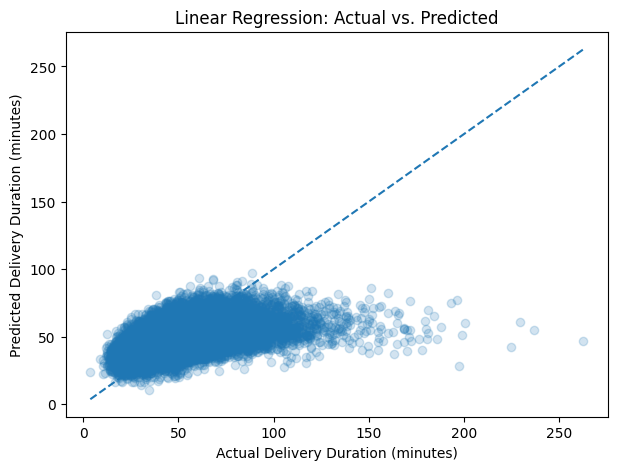

In [9]:
# Compare actual and predicted delivery duration

plt.figure(figsize=(7, 5))
plt.scatter(y_validation, linear_val_pred, alpha=0.2)
min_val = min(y_validation.min(), linear_val_pred.min())
max_val = max(y_validation.max(), linear_val_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual Delivery Duration (minutes)")
plt.ylabel("Predicted Delivery Duration (minutes)")
plt.title("Linear Regression: Actual vs. Predicted")
plt.show()

#### Model 2: XGBoost

XGBoost is used to capture more complex relationships between the predictors and delivery duration.

In [10]:
# Fit initial XGBoost model
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
print("XGBoost training complete.")

XGBoost training complete.


In [11]:
# Predict on validation data

xgb_val_pred = xgb_model.predict(X_validation)
xgb_mae = mean_absolute_error(y_validation, xgb_val_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_validation, xgb_val_pred))
xgb_r2 = r2_score(y_validation, xgb_val_pred)
xgb_bias = np.mean(xgb_val_pred - y_validation)

print(f"MAE:  {xgb_mae:.2f} minutes")
print(f"RMSE: {xgb_rmse:.2f} minutes")
print(f"R²:   {xgb_r2:.3f}")
print(f"Bias: {xgb_bias:.2f} minutes")

MAE:  10.52 minutes
RMSE: 14.59 minutes
R²:   0.363
Bias: 0.20 minutes


#### Tuning XGBoost

In [12]:
# Compare a small set of XGBoost configurations

xgb_configs = [
    {"name": "Current", "n_estimators": 300, "learning_rate": 0.05, "max_depth": 6},
    {"name": "Shallower", "n_estimators": 400, "learning_rate": 0.05, "max_depth": 4},
    {"name": "More Trees", "n_estimators": 500, "learning_rate": 0.03, "max_depth": 6},
    {"name": "Deeper", "n_estimators": 300, "learning_rate": 0.05, "max_depth": 8}
]
xgb_tuning_results = []
for config in xgb_configs:
    model = XGBRegressor(
        n_estimators=config["n_estimators"],
        learning_rate=config["learning_rate"],
        max_depth=config["max_depth"],
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    predictions = model.predict(X_validation)

    xgb_tuning_results.append({
        "Model": config["name"],
        "Trees": config["n_estimators"],
        "Learning Rate": config["learning_rate"],
        "Max Depth": config["max_depth"],
        "MAE": mean_absolute_error(y_validation, predictions)
    })
xgb_tuning_results = pd.DataFrame(xgb_tuning_results)
xgb_tuning_results.sort_values("MAE").round(3)

,Model,Trees,Learning Rate,Max Depth,MAE
3,Deeper,300,0.05,8,10.468
0,Current,300,0.05,6,10.518
2,More Trees,500,0.03,6,10.524
1,Shallower,400,0.05,4,10.646


In [13]:
# Fit selected XGBoost model

xgb_selected = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1
)

xgb_selected.fit(X_train, y_train)
xgb_val_pred = xgb_selected.predict(X_validation)
print("Selected XGBoost model training complete.")

Selected XGBoost model training complete.


In [14]:
# Evaluate selected XGBoost model

xgb_mae = mean_absolute_error(y_validation, xgb_val_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_validation, xgb_val_pred))
xgb_r2 = r2_score(y_validation, xgb_val_pred)
xgb_bias = np.mean(xgb_val_pred - y_validation)

print(f"MAE:  {xgb_mae:.2f} minutes")
print(f"RMSE: {xgb_rmse:.2f} minutes")
print(f"R²:   {xgb_r2:.3f}")
print(f"Bias: {xgb_bias:.2f} minutes")

MAE:  10.47 minutes
RMSE: 14.53 minutes
R²:   0.369
Bias: 0.21 minutes


#### Validation Model Comparison

In [15]:
# Compare validation performance

validation_results = pd.DataFrame({
    "Model": ["Linear Regression", "XGBoost"],
    "MAE": [linear_mae, xgb_mae],
    "RMSE": [linear_rmse, xgb_rmse],
    "R²": [linear_r2, xgb_r2],
    "Bias": [linear_bias, xgb_bias]
})

validation_results.sort_values("MAE").round(3)

,Model,MAE,RMSE,R²,Bias
1,XGBoost,10.468,14.526,0.369,0.211
0,Linear Regression,11.313,15.584,0.274,0.237


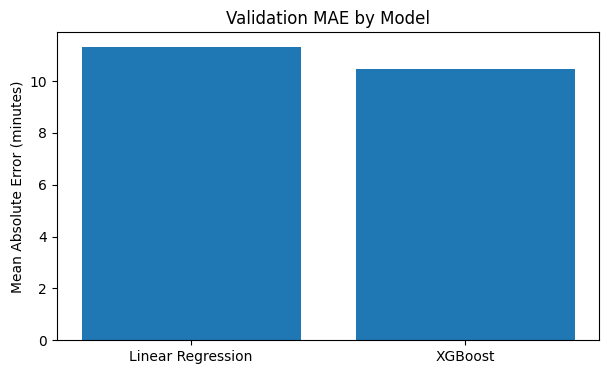

In [16]:
# Compare model prediction errors

plt.figure(figsize=(7, 4))

plt.bar(validation_results["Model"], validation_results["MAE"])

plt.ylabel("Mean Absolute Error (minutes)")
plt.title("Validation MAE by Model")

plt.show()

#### XGBoost: Actual vs. Predicted

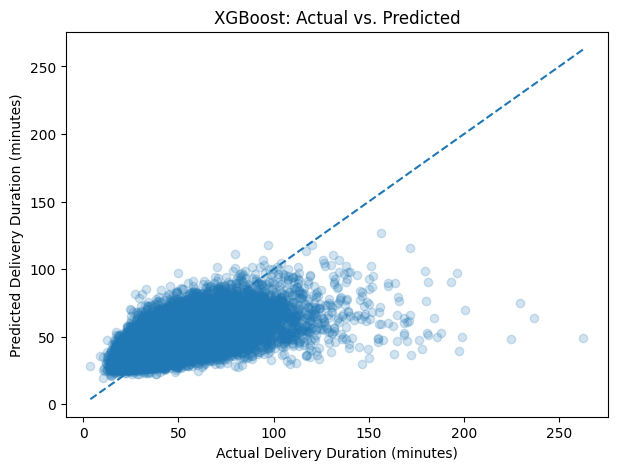

In [17]:
# Compare actual and predicted delivery duration for XGBoost

plt.figure(figsize=(7, 5))
plt.scatter(y_validation, xgb_val_pred, alpha=0.2)

min_val = min(y_validation.min(), xgb_val_pred.min())
max_val = max(y_validation.max(), xgb_val_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual Delivery Duration (minutes)")
plt.ylabel("Predicted Delivery Duration (minutes)")
plt.title("XGBoost: Actual vs. Predicted")
plt.show()

#### Feature Importance by Model

XGBoost identified outstanding orders, dashers on shift, and estimated driving duration as its most important predictors. Order hour also played a larger role compared with Linear Regression, suggesting that delivery times may have more complex relationships with the time an order is placed.

In [19]:
# Linear Regression permutation importance

linear_importance = permutation_importance(
    linear_model,
    X_validation,
    y_validation,
    scoring="neg_mean_absolute_error",
    n_repeats=3,
    random_state=SEED,
    n_jobs=2
)

linear_features = pd.DataFrame({
    "Feature": X_validation.columns,
    "Importance": linear_importance.importances_mean
}).sort_values("Importance", ascending=False)

linear_features.head(10)

,Feature,Importance
10,total_outstanding_orders,11.697640
8,total_onshift_dashers,5.853150
12,estimated_store_to_consumer_driving_duration,1.060031
9,total_busy_dashers,0.806727
3,subtotal,0.406903
11,estimated_order_place_duration,0.201812
0,order_hour,0.184111
96,order_protocol_5.0,0.098066
13,market_id_1.0,0.091520
92,order_protocol_1.0,0.081179


In [20]:
# XGBoost permutation importance

xgb_importance = permutation_importance(
    xgb_selected,
    X_validation,
    y_validation,
    scoring="neg_mean_absolute_error",
    n_repeats=3,
    random_state=SEED,
    n_jobs=2
)

xgb_features = pd.DataFrame({
    "Feature": X_validation.columns,
    "Importance": xgb_importance.importances_mean
}).sort_values("Importance", ascending=False)

xgb_features.head(10)

,Feature,Importance
10,total_outstanding_orders,8.778178
8,total_onshift_dashers,5.529071
12,estimated_store_to_consumer_driving_duration,1.126115
9,total_busy_dashers,1.093334
0,order_hour,0.958647
3,subtotal,0.466265
11,estimated_order_place_duration,0.232538
95,order_protocol_4.0,0.174740
5,max_item_price,0.145764
4,min_item_price,0.110283


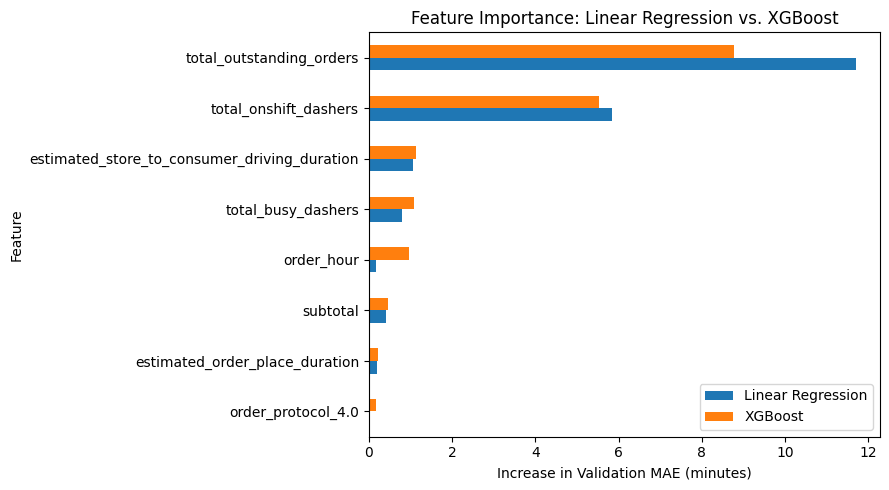

In [21]:
# Compare feature importance across models

top_features = xgb_features.head(8)["Feature"]
importance_comparison = pd.DataFrame({
    "Linear Regression": linear_features.set_index("Feature")["Importance"],
    "XGBoost": xgb_features.set_index("Feature")["Importance"]
}).loc[top_features]

importance_comparison.sort_values("XGBoost").plot(
    kind="barh",
    figsize=(9, 5)
)

plt.xlabel("Increase in Validation MAE (minutes)")
plt.ylabel("Feature")
plt.title("Feature Importance: Linear Regression vs. XGBoost")
plt.legend()
plt.tight_layout()
plt.show()

Both models identified outstanding orders and dashers on shift as the most important predictors. Linear Regression showed greater sensitivity to outstanding orders, while XGBoost relied more on order hour and busy dashers. This suggests that the models use some of the same information differently when predicting delivery duration.

#### Final Model Evaluation

XGBoost was selected based on its lower validation MAE. Both models are now evaluated on the test set to compare their performance on unseen data.

In [22]:
# Evaluate both models on the test set

linear_test_pred = linear_model.predict(X_test)
xgb_test_pred = xgb_selected.predict(X_test)

test_results = pd.DataFrame({
    "Model": ["Linear Regression", "XGBoost"],
    "MAE": [
        mean_absolute_error(y_test, linear_test_pred),
        mean_absolute_error(y_test, xgb_test_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, linear_test_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_test_pred))
    ],
    "R²": [
        r2_score(y_test, linear_test_pred),
        r2_score(y_test, xgb_test_pred)
    ],
    "Bias": [
        np.mean(linear_test_pred - y_test),
        np.mean(xgb_test_pred - y_test)
    ]
})

test_results.sort_values("MAE").round(3)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


,Model,MAE,RMSE,R²,Bias
1,XGBoost,10.489,14.683,0.355,0.229
0,Linear Regression,11.384,15.720,0.260,0.200


XGBoost maintained its advantage on the test set, achieving a lower MAE and RMSE than Linear Regression. Its test performance was also close to its validation results, suggesting the model generalizes reasonably well to similar orders. However, unusually long deliveries remain difficult to predict.

#### Exporting Results

The validation results, test results, and feature importance scores are saved for the team's final model comparison.

In [23]:
# Export validation and test results

validation_results.to_csv(
    RESULTS / "models_1_2_validation_results.csv",
    index=False
)

test_results.to_csv(
    RESULTS / "models_1_2_test_results.csv",
    index=False
)

# Combine feature importance from both models
importance_results = pd.concat([
    linear_features.assign(Model="Linear Regression"),
    xgb_features.assign(Model="XGBoost")
], ignore_index=True)

importance_results = importance_results[
    ["Model", "Feature", "Importance"]
]

importance_results.to_csv(
    RESULTS / "models_1_2_importance.csv",
    index=False
)
print("Results exported successfully.")

Results exported successfully.
